In [4]:
import numpy as np
from matplotlib import pyplot as plt 
import xarray as xr 

In [5]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), 
                       known_hash=None)
files.sort()

In [6]:
P = np.load(files[0])
S = np.load(files[1])
T = np.load(files[2])
date = np.load(files[3])
lat = np.load(files[4])
levels = np.load(files[5])
lon = np.load(files[6])

In [9]:
S.shape

(78, 75)

In [11]:
da_s = xr.DataArray(S, dims=['depth', 'date'],
                    coords={'depth':levels, 'date':date})
da_s

<xarray.DataArray (depth: 78, date: 75)> Size: 47kB
array([[35.6389389 , 35.51495743, 35.57297134, ..., 35.82093811,
        35.77793884, 35.66891098],
       [35.63393784, 35.5219574 , 35.57397079, ..., 35.81093216,
        35.58389664, 35.66791153],
       [35.6819458 , 35.52595901, 35.57297134, ..., 35.79592896,
        35.66290665, 35.66591263],
       ...,
       [34.91585922, 34.92390442, 34.92390442, ..., 34.93481064,
        34.94081116, 34.94680786],
       [34.91585922, 34.92390442, 34.92190552, ..., 34.93280792,
        34.93680954, 34.94380951],
       [34.91785812, 34.92390442, 34.92390442, ...,         nan,
        34.93680954,         nan]])
Coordinates:
  * depth    (depth) int64 624B 0 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75 76 77
  * date     (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 2014-0...

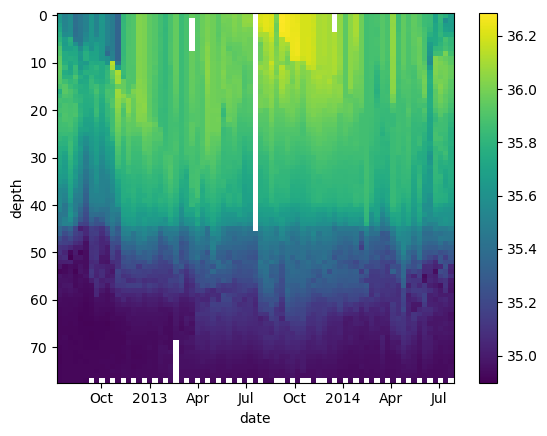

In [13]:
da_s.plot(yincrease=False)

In [14]:
da_s.attrs['units'] = 'PSU'
da_s.attrs['standard_name'] = 'sea_water_salinity'

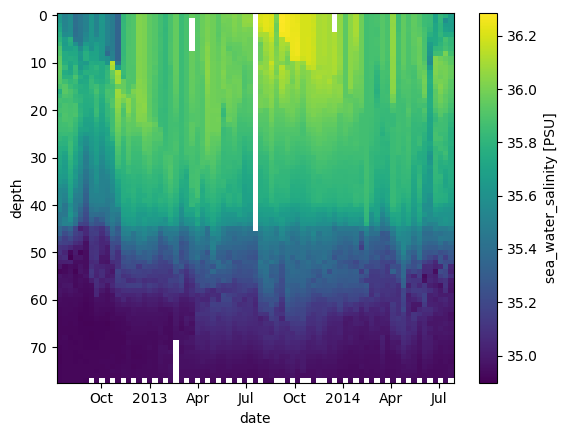

In [16]:
da_s.plot(yincrease=False)

In [17]:
argo = xr.Dataset(
    data_vars={
        'salinity': (('depth','date'), S),
        'temperature' : (('depth','date'),T), 
        'pressure' : (('depth','date'), P), 
    }, 
    coords={
        'depth':levels, 
        'date':date
    }
)
argo

<xarray.Dataset> Size: 142kB
Dimensions:      (depth: 78, date: 75)
Coordinates:
  * depth        (depth) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
Data variables:
    salinity     (depth, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (depth, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (depth, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

In [18]:
argo.coords['lon'] = ('date',lon)
argo.coords['lat'] = ('date',lat)
argo

<xarray.Dataset> Size: 143kB
Dimensions:      (depth: 78, date: 75)
Coordinates:
  * depth        (depth) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
    lon          (date) float64 600B -39.13 -37.28 -36.9 ... -34.11 -34.38
    lat          (date) float64 600B 47.19 46.72 46.45 ... 42.6 42.46 42.38
Data variables:
    salinity     (depth, date) float64 47kB 35.64 35.51 35.57 ... nan 34.94 nan
    temperature  (depth, date) float64 47kB 18.97 18.44 19.1 ... nan 3.714 nan
    pressure     (depth, date) float64 47kB 6.8 6.1 6.5 5.0 ... nan 2e+03 nan

In [19]:
argo*1000

<xarray.Dataset> Size: 143kB
Dimensions:      (depth: 78, date: 75)
Coordinates:
  * depth        (depth) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
  * date         (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 20...
    lon          (date) float64 600B -39.13 -37.28 -36.9 ... -34.11 -34.38
    lat          (date) float64 600B 47.19 46.72 46.45 ... 42.6 42.46 42.38
Data variables:
    salinity     (depth, date) float64 47kB 3.564e+04 3.551e+04 ... nan
    temperature  (depth, date) float64 47kB 1.897e+04 1.844e+04 ... nan
    pressure     (depth, date) float64 47kB 6.8e+03 6.1e+03 ... 2e+06 nan

In [20]:
argo.salinity.sel(depth=2)

<xarray.DataArray 'salinity' (date: 75)> Size: 600B
array([35.6819458 , 35.52595901, 35.57297134, 35.40494537, 35.45091629,
       35.50192261, 35.62397766, 35.51696014, 35.62797546, 35.52292252,
       35.47383118, 35.33785629, 35.81896591, 35.88694   , 35.90187836,
       36.02391815, 36.00475693, 35.94187927, 35.91583252, 35.86392212,
       35.81995392, 35.88601303, 35.95079422, 35.84091568, 35.87992477,
               nan, 35.92179108, 35.96979141, 36.0008316 , 35.98083115,
       35.92887878, 35.98091888, 35.9838829 , 36.01884842, 35.99092484,
       36.04689026, 36.04185867,         nan, 36.19193268, 36.22789764,
       36.20986557, 35.97589874, 36.2779007 , 36.25889969, 36.2418251 ,
       36.23685837, 36.19781876, 36.19785309, 36.17692184, 36.1048851 ,
       36.11392212, 36.09080505,         nan, 36.05675888, 35.93374634,
       36.04291534, 36.10183716, 35.97779083, 35.86592102, 35.87791824,
       35.88392258, 35.92078781, 35.88601303, 36.05178833, 35.85883713,
       35.94878769, 35.8938446 , 35.94379425, 35.90884018, 35.84893036,
       35.83496857, 35.71691132, 35.79592896, 35.66290665, 35.66591263])
Coordinates:
    depth    int64 8B 2
  * date     (date) datetime64[ns] 600B 2012-07-13T22:33:06.019200 ... 2014-0...
    lon      (date) float64 600B -39.13 -37.28 -36.9 ... -33.83 -34.11 -34.38
    lat      (date) float64 600B 47.19 46.72 46.45 46.23 ... 42.6 42.46 42.38

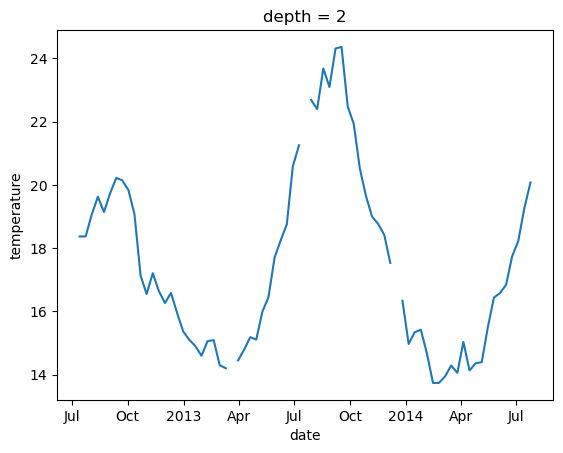

In [24]:
argo.temperature.sel(depth=2).plot()

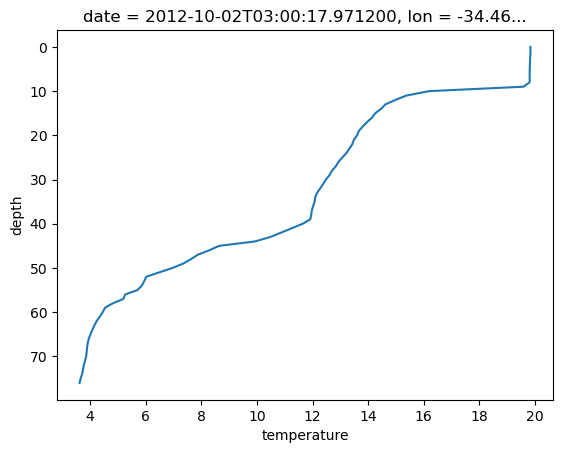

In [29]:
argo.temperature.sel(date='2012-10-02').plot(y='depth',
                                            yincrease=False)

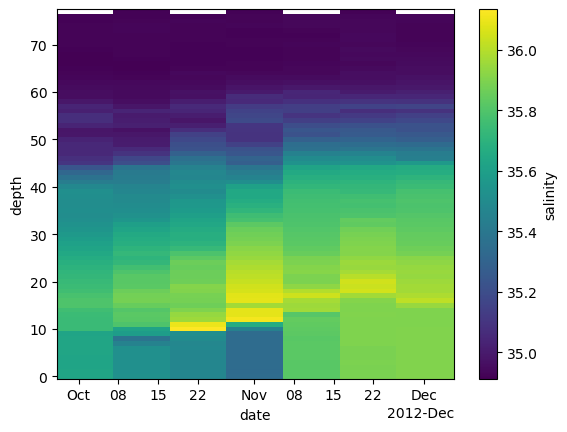

In [30]:
argo.salinity.sel(date=slice('2012-10-01', '2012-12-01')).plot()

In [31]:
argo.salinity.sel(date=slice('2012-10-01', '2012-12-01'))

<xarray.DataArray 'salinity' (depth: 78, date: 7)> Size: 4kB
array([[35.63097763, 35.52592468, 35.47483063, 35.33785629, 35.81896591,
        35.8889389 , 35.90187836],
       [35.63097763, 35.52292252, 35.47483063, 35.33685684, 35.81796646,
        35.88793945, 35.90187836],
       [35.62797546, 35.52292252, 35.47383118, 35.33785629, 35.81896591,
        35.88694   , 35.90187836],
       [35.62697601, 35.52192307, 35.47383118, 35.33785629, 35.81896591,
        35.89193726, 35.90187836],
       [35.62797546, 35.52192307, 35.47383118, 35.33785629, 35.81996536,
        35.88993835, 35.90187836],
       [35.62897873, 35.52292252, 35.47483063, 35.33785629, 35.81996536,
        35.88993835, 35.90187836],
       [35.62997818, 35.51892471, 35.48183441, 35.33785629, 35.81996536,
        35.88993835, 35.90187836],
       [35.63197708, 35.44991302, 35.47983551, 35.33785629, 35.81996536,
        35.89683914, 35.90187836],
       [35.63097763, 35.38090134, 35.4948349 , 35.33785629, 35.81896591,
        35.89583969, 35.90187836],
       [35.62697601, 35.58792114, 35.51083755, 35.33985519, 35.82497025,
        35.89683914, 35.90187836],
...
       [34.91690445, 34.92385483, 34.91975403, 34.91980362, 34.92385483,
        34.93680573, 34.93885422],
       [34.92190552, 34.92485428, 34.91975403, 34.92080688, 34.92485428,
        34.94480515, 34.9328537 ],
       [34.92390442, 34.92285538, 34.92176056, 34.92280579, 34.92985535,
        34.93280411, 34.92785645],
       [34.92390442, 34.92385483, 34.92375946, 34.92480469, 34.92685318,
        34.93780899, 34.92485428],
       [34.92390442, 34.92285538, 34.92575836, 34.92181015, 34.92085648,
        34.93680954, 34.92385483],
       [34.92590332, 34.9288559 , 34.92575836, 34.92181015, 34.92685318,
        34.93481064, 34.92585373],
       [34.92490387, 34.92785645, 34.92475891, 34.92781067, 34.93385696,
        34.93380737, 34.92385864],
       [34.92190552, 34.92385864, 34.93076324, 34.9268074 , 34.93585968,
        34.93481064, 34.92985916],
       [34.92090607, 34.92185974, 34.92176437, 34.9228096 , 34.93285751,
        34.93180847, 34.92786026],
       [        nan, 34.91985703,         nan, 34.92181015,         nan,
        34.92181015,         nan]])
Coordinates:
  * depth    (depth) int64 624B 0 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75 76 77
  * date     (date) datetime64[ns] 56B 2012-10-02T03:00:17.971200 ... 2012-12...
    lon      (date) float64 56B -34.46 -33.78 -32.97 -32.55 -32.43 -32.29 -32.17
    lat      (date) float64 56B 44.96 44.68 44.13 43.64 43.07 42.66 42.51

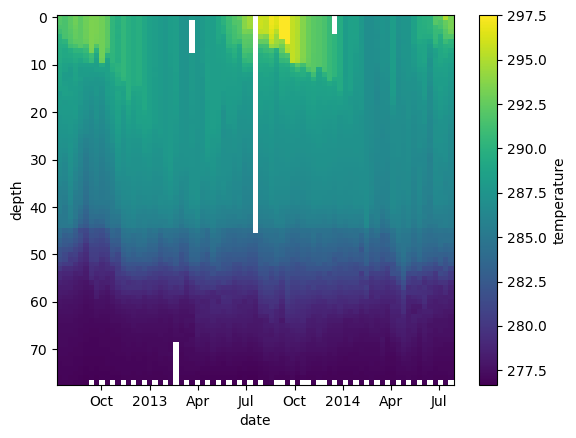

In [32]:
temp_kelvin = argo.temperature + 273.15
temp_kelvin.plot(yincrease=False)

In [33]:
argo_mean =argo.mean(dim='date')
argo_mean

<xarray.Dataset> Size: 2kB
Dimensions:      (depth: 78)
Coordinates:
  * depth        (depth) int64 624B 0 1 2 3 4 5 6 7 ... 70 71 72 73 74 75 76 77
Data variables:
    salinity     (depth) float64 624B 35.91 35.9 35.9 35.9 ... 34.94 34.94 34.93
    temperature  (depth) float64 624B 17.6 17.57 17.51 ... 3.789 3.73 3.662
    pressure     (depth) float64 624B 6.435 10.57 15.54 ... 1.95e+03 1.999e+03

In [38]:
gistemp_file = pooch.retrieve(
    'https://data.giss.nasa.gov/pub/gistemp/gistemp1200_GHCNv4_ERSSTv5.nc.gz',
    known_hash=None,
    processor=pooch.Decompress(),
)
gistemp_file

'/home/danielmw/.cache/pooch/d87657ed105a8945c211515b79b884c2-gistemp1200_GHCNv4_ERSSTv5.nc.gz.decomp'

In [40]:
ds = xr.open_dataset('/data9/G5053/data/danielmw/file.nc.gz.decomp')

In [41]:
ds

<xarray.Dataset> Size: 112MB
Dimensions:      (lat: 90, lon: 180, time: 1730, nv: 2)
Coordinates:
  * lat          (lat) float32 360B -89.0 -87.0 -85.0 -83.0 ... 85.0 87.0 89.0
  * lon          (lon) float32 720B -179.0 -177.0 -175.0 ... 175.0 177.0 179.0
  * time         (time) datetime64[ns] 14kB 1880-01-15 1880-02-15 ... 2024-02-15
Dimensions without coordinates: nv
Data variables:
    time_bnds    (time, nv) datetime64[ns] 28kB ...
    tempanomaly  (time, lat, lon) float32 112MB ...
Attributes:
    title:        GISTEMP Surface Temperature Analysis
    institution:  NASA Goddard Institute for Space Studies
    source:       http://data.giss.nasa.gov/gistemp/
    Conventions:  CF-1.6
    history:      Created 2024-03-08 11:37:27 by SBBX_to_nc 2.0 - ILAND=1200,...

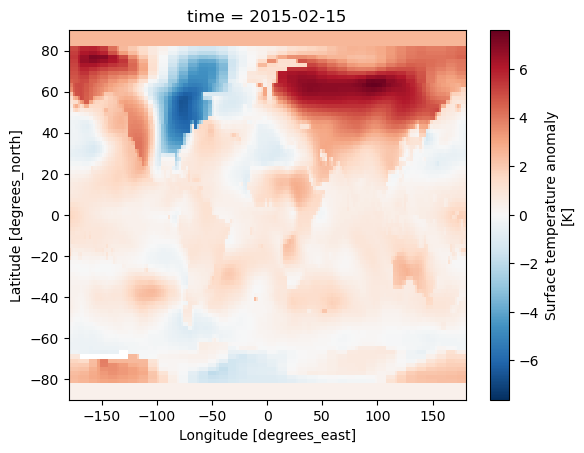

In [46]:
ds.tempanomaly.sel(time='2015-02-15').plot()

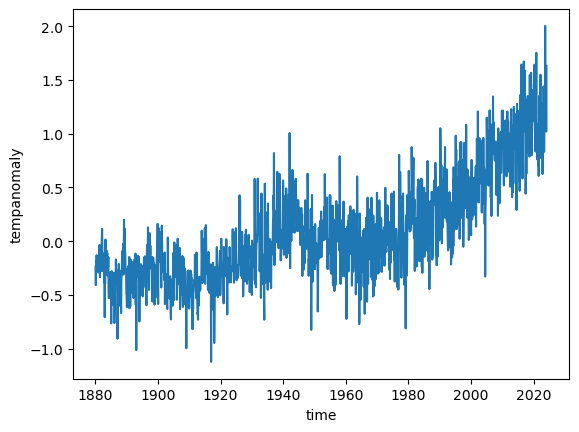

In [47]:
ds.tempanomaly.mean(dim=('lon','lat')).plot()

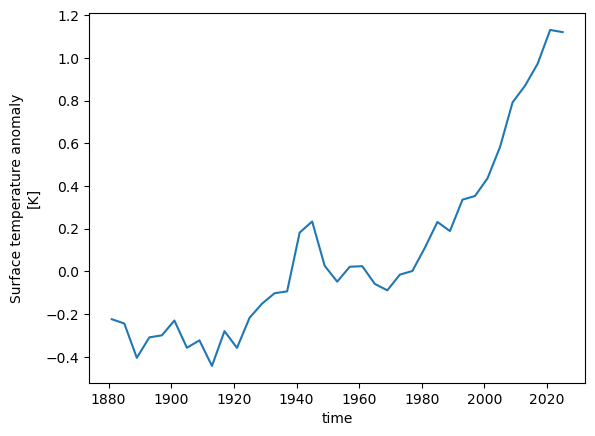

In [53]:
ds.tempanomaly.resample(time='4YE').mean(dim=('time','lon','lat')).plot()